# Tugas 3 — Agglomerative Hierarchical Clustering

**Mata Kuliah:** Data Mining

## Deskripsi
Algoritma **Agglomerative Clustering** termasuk *hierarchical clustering* dengan pendekatan **bottom-up**:

1. Setiap data dimulai sebagai klaster sendiri (awalnya jumlah klaster = jumlah data).
2. Hitung **matriks jarak** antar semua klaster.
3. Gabungkan **dua klaster terdekat** menjadi satu.
4. **Perbarui matriks jarak**, lalu ulangi langkah 2 dan 3 sampai semua data tergabung dalam satu klaster.
5. Riwayat penggabungan divisualisasikan sebagai **dendrogram**, lalu jumlah klaster ditentukan dengan memotong dendrogram.

Studi kasus: **10 mahasiswa** dengan atribut **Nilai Tugas** dan **Nilai Ujian**. Jumlah data kecil supaya setiap langkah (termasuk **matriks jarak di tiap iterasi**) bisa di-*trace* manual untuk laporan.

**Linkage yang dipakai untuk perhitungan manual: *single linkage*** (jarak antar klaster = jarak **minimum** antar anggotanya), karena paling mudah dihitung tangan.

Catatan penting: agglomerative **tidak berhenti di 2 klaster**. Algoritma jalan terus sampai 1 klaster; **jumlah klaster final ditentukan dari data** (lihat Section 5) dan untuk data ini ternyata **3 klaster**.

## 1. Import Library dan Data

### Penjelasan kode

- `numpy`, `pandas`, `matplotlib` untuk komputasi numerik dan visualisasi.
- `scipy.spatial.distance.pdist` dan `squareform` untuk menghitung matriks jarak Euclidean.
- `scipy.cluster.hierarchy.linkage`, `dendrogram`, `fcluster` adalah API hierarchical clustering SciPy (untuk verifikasi dan memotong dendrogram).
- `sklearn.cluster.AgglomerativeClustering` sebagai pembanding.
- `IPython.display.display` dipakai untuk menampilkan beberapa tabel matriks dalam satu sel.
- Dataset: **10 mahasiswa** (A–J) dengan dua atribut numerik `Tugas` dan `Ujian` (skala 0–10, jadi tidak perlu standarisasi).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering
from IPython.display import display

# 10 mahasiswa dengan dua nilai (skala 0..10)
data = pd.DataFrame({
    'Mhs':   ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Tugas': [1, 2, 2, 5, 6, 5, 9, 9, 8, 10],
    'Ujian': [2, 2, 3, 5, 5, 6, 9, 8, 9, 10],
})
data

,Mhs,Tugas,Ujian
0,A,1,2
1,B,2,2
2,C,2,3
3,D,5,5
4,E,6,5
5,F,5,6
6,G,9,9
7,H,9,8
8,I,8,9
9,J,10,10


### Penjelasan kode

Scatter plot 10 mahasiswa pada bidang Tugas vs Ujian. Secara kasat mata terlihat **tiga kelompok**:

- Nilai **rendah**: A, B, C (kiri bawah).
- Nilai **menengah**: D, E, F (tengah).
- Nilai **tinggi**: G, H, I, J (kanan atas).

Inilah alasan jumlah klaster yang benar untuk data ini bukan 2, melainkan **3** (akan dibuktikan dari dendrogram di Section 5).

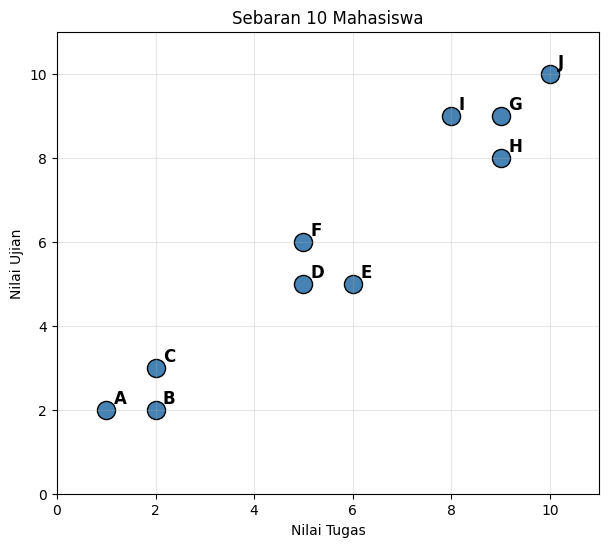

In [2]:
X = data[['Tugas', 'Ujian']].values
names = data['Mhs'].values

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], s=170, c='steelblue', edgecolors='k')
for i, nm in enumerate(names):
    plt.annotate(nm, (X[i, 0] + 0.15, X[i, 1] + 0.15), fontsize=12, fontweight='bold')
plt.xlabel('Nilai Tugas')
plt.ylabel('Nilai Ujian')
plt.title('Sebaran 10 Mahasiswa')
plt.grid(alpha=0.3)
plt.xlim(0, 11); plt.ylim(0, 11)
plt.show()

## 2. Matriks Jarak Awal (Proximity Matrix)

Inilah **matriks yang dipakai untuk menghitung**. Rumus jarak Euclidean dua titik $p$ dan $q$:

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2}$$

**Keterangan simbol:**
- $d(p, q)$ — jarak (Euclidean) antara titik $p$ dan titik $q$; makin kecil nilainya berarti dua titik makin **mirip/dekat**.
- $p$ dan $q$ — dua titik data (mahasiswa) yang sedang dihitung jaraknya. Tiap titik punya 2 nilai (fitur).
- $p_1, p_2$ — nilai fitur titik $p$: $p_1$ = Nilai **Tugas**, $p_2$ = Nilai **Ujian**.
- $q_1, q_2$ — nilai fitur titik $q$: $q_1$ = Nilai **Tugas**, $q_2$ = Nilai **Ujian**.
- $\sqrt{\;\;}$ — akar kuadrat; $(\;)^2$ — pangkat dua (selisih dikuadratkan supaya selalu positif).

Contoh: titik A(1, 2) dan B(2, 2) → $d = \sqrt{(1-2)^2 + (2-2)^2} = \sqrt{1} = 1{,}0$.

Karena ada 10 data, matriks berukuran **10 × 10**, simetris, diagonal nol. Jumlah pasangan unik = $\binom{10}{2} = 45$ (notasi $\binom{n}{2}$ = banyak cara memilih 2 titik dari $n$ titik).

### Penjelasan kode

- `pdist(X)` menghitung jarak Euclidean semua pasangan, `squareform` mengubahnya menjadi matriks 10 × 10.
- `df_jarak` diberi label baris/kolom A–J dan dibulatkan 2 desimal supaya mudah di-*trace* tangan.
- Inilah titik awal algoritma: cari **nilai terkecil di luar diagonal** untuk penggabungan pertama.

In [3]:
dist_mat = squareform(pdist(X, metric='euclidean'))
df_jarak = pd.DataFrame(np.round(dist_mat, 2), index=names, columns=names)
df_jarak

,A,B,C,D,E,F,G,H,I,J
A,0.00,1.00,1.41,5.00,5.83,5.66,10.63,10.00,9.90,12.04
B,1.00,0.00,1.00,4.24,5.00,5.00,9.90,9.22,9.22,11.31
C,1.41,1.00,0.00,3.61,4.47,4.24,9.22,8.60,8.49,10.63
D,5.00,4.24,3.61,0.00,1.00,1.00,5.66,5.00,5.00,7.07
E,5.83,5.00,4.47,1.00,0.00,1.41,5.00,4.24,4.47,6.40
F,5.66,5.00,4.24,1.00,1.41,0.00,5.00,4.47,4.24,6.40
G,10.63,9.90,9.22,5.66,5.00,5.00,0.00,1.00,1.00,1.41
H,10.00,9.22,8.60,5.00,4.24,4.47,1.00,0.00,1.41,2.24
I,9.90,9.22,8.49,5.00,4.47,4.24,1.00,1.41,0.00,2.24
J,12.04,11.31,10.63,7.07,6.40,6.40,1.41,2.24,2.24,0.00


### Penjelasan kode

15 pasangan terkecil dicetak terurut. Pasangan dengan jarak paling kecil adalah kandidat penggabungan pertama. Berguna untuk cek cepat sebelum menjalankan algoritma penuh.

In [4]:
pasangan = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        pasangan.append({'Pasangan': f'{names[i]}-{names[j]}', 'Jarak': round(dist_mat[i, j], 4)})
df_pasangan = pd.DataFrame(pasangan).sort_values('Jarak').reset_index(drop=True)
df_pasangan.head(15)

,Pasangan,Jarak
0,A-B,1.0000
1,B-C,1.0000
2,D-E,1.0000
3,D-F,1.0000
4,G-I,1.0000
5,G-H,1.0000
6,A-C,1.4142
7,E-F,1.4142
8,H-I,1.4142
9,G-J,1.4142


## 3. Langkah demi Langkah (Manual, Single Linkage)

**Single linkage**: jarak antar dua klaster = jarak **minimum** antar anggotanya.

$$d_{\text{single}}(C_i, C_j) = \min_{x \in C_i,\; y \in C_j} d(x, y)$$

**Keterangan simbol:**
- $C_i, C_j, C_k$ — klaster (kelompok) ke-$i$, ke-$j$, ke-$k$. Di awal tiap klaster berisi 1 titik.
- $x \in C_i$ — sebuah titik $x$ yang menjadi **anggota** klaster $C_i$ (lambang $\in$ artinya "anggota dari").
- $y \in C_j$ — sebuah titik $y$ anggota klaster $C_j$.
- $d(x, y)$ — jarak Euclidean antar dua titik (rumus pada Section 2).
- $\min$ — ambil nilai **terkecil**. Jadi jarak dua klaster = pasangan anggota yang **paling dekat**.
- $C_i \cup C_j$ — gabungan klaster $C_i$ dan $C_j$ menjadi satu klaster (lambang $\cup$ = union/gabungan).

Aturan update matriks (cara hitung manual): setelah klaster $C_i$ dan $C_j$ digabung, jarak gabungan ke klaster lain $C_k$ adalah:

$$d(C_i \cup C_j,\; C_k) = \min\big(d(C_i, C_k),\; d(C_j, C_k)\big)$$

Artinya: jarak klaster gabungan ke $C_k$ = ambil yang **lebih kecil** antara (jarak $C_i$ ke $C_k$) dan (jarak $C_j$ ke $C_k$).

Jadi tiap iterasi: **(1)** lihat matriks, **(2)** cari sel terkecil, **(3)** gabung, **(4)** perbarui matriks dengan rumus MIN di atas. Sel di bawah menampilkan **matriks pada setiap iterasi** lengkap.

### Penjelasan kode

Fungsi `agglomerative_single_trace` merekam **snapshot matriks jarak di setiap iterasi**:

- `clusters` = list anggota tiap klaster, awalnya tiap mahasiswa jadi klaster sendiri.
- `M` = matriks jarak yang terus diperkecil; diagonal diisi `inf` supaya tidak terpilih sebagai minimum.
- Tiap iterasi: simpan matriks saat ini, cari sel minimum dengan `np.argmin`, gabung dua klaster.
- **Update single linkage**: baris/kolom hasil gabungan = `np.minimum(baris_i, baris_j)` (persis rumus MIN), lalu baris/kolom yang sudah digabung dihapus.
- Hasilnya disimpan di `steps` untuk ditampilkan rapi.

In [5]:
def agglomerative_single_trace(X, names):
    clusters = [[nm] for nm in names]
    M = squareform(pdist(X)).astype(float)
    np.fill_diagonal(M, np.inf)
    steps = []

    while len(clusters) > 1:
        label_now = ['{' + ','.join(c) + '}' for c in clusters]
        # snapshot matriks saat ini (diagonal ditampilkan 0)
        disp = M.copy()
        np.fill_diagonal(disp, 0.0)
        mat_df = pd.DataFrame(np.round(disp, 3), index=label_now, columns=label_now)

        # cari pasangan terdekat (sel minimum)
        i, j = np.unravel_index(np.argmin(M), M.shape)
        if i > j:
            i, j = j, i
        d = M[i, j]
        merged = clusters[i] + clusters[j]

        # update single linkage: baris/kolom i = min(i, j); hapus j
        new_row = np.minimum(M[i, :], M[j, :])
        new_row[i] = np.inf
        M[i, :] = new_row
        M[:, i] = new_row
        M = np.delete(M, j, axis=0)
        M = np.delete(M, j, axis=1)
        clusters[i] = merged
        del clusters[j]

        steps.append({
            'iter': len(steps) + 1,
            'n_before': len(label_now),
            'matrix': mat_df,
            'min_pair': (label_now[i], label_now[j]),
            'dist': round(d, 4),
            'clusters_after': ['{' + ','.join(c) + '}' for c in clusters],
        })
    return steps

steps = agglomerative_single_trace(X, names)
print(f'Total iterasi penggabungan: {len(steps)}  (untuk {len(names)} data = {len(names)} - 1)')

Total iterasi penggabungan: 9  (untuk 10 data = 10 - 1)


### Penjelasan kode

Menampilkan **matriks jarak di setiap iterasi** beserta keputusan penggabungan. Output sel ini adalah bahan utama laporan step-by-step:

- Header `ITERASI n` dengan jumlah klaster saat itu.
- Tabel matriks jarak antar klaster (inilah "matriks yang dipakai menghitung").
- Baris keputusan: pasangan dengan jarak minimum yang digabung.
- Komposisi klaster sesudah penggabungan.

In [6]:
for s in steps:
    print(f"===================== ITERASI {s['iter']}  ({s['n_before']} klaster) =====================")
    print('Matriks jarak antar klaster saat ini:')
    display(s['matrix'])
    print(f"Jarak minimum = {s['dist']}  pada pasangan  {s['min_pair'][0]}  dan  {s['min_pair'][1]}")
    print(f"Gabungkan -> klaster sekarang: {', '.join(s['clusters_after'])}")
    print()

===================== ITERASI 1  (10 klaster) =====================
Matriks jarak antar klaster saat ini:


,{A},{B},{C},{D},{E},{F},{G},{H},{I},{J}
{A},0.000,1.000,1.414,5.000,5.831,5.657,10.630,10.000,9.899,12.042
{B},1.000,0.000,1.000,4.243,5.000,5.000,9.899,9.220,9.220,11.314
{C},1.414,1.000,0.000,3.606,4.472,4.243,9.220,8.602,8.485,10.630
{D},5.000,4.243,3.606,0.000,1.000,1.000,5.657,5.000,5.000,7.071
{E},5.831,5.000,4.472,1.000,0.000,1.414,5.000,4.243,4.472,6.403
{F},5.657,5.000,4.243,1.000,1.414,0.000,5.000,4.472,4.243,6.403
{G},10.630,9.899,9.220,5.657,5.000,5.000,0.000,1.000,1.000,1.414
{H},10.000,9.220,8.602,5.000,4.243,4.472,1.000,0.000,1.414,2.236
{I},9.899,9.220,8.485,5.000,4.472,4.243,1.000,1.414,0.000,2.236
{J},12.042,11.314,10.630,7.071,6.403,6.403,1.414,2.236,2.236,0.000


Jarak minimum = 1.0  pada pasangan  {A}  dan  {B}
Gabungkan -> klaster sekarang: {A,B}, {C}, {D}, {E}, {F}, {G}, {H}, {I}, {J}

===================== ITERASI 2  (9 klaster) =====================
Matriks jarak antar klaster saat ini:


,"{A,B}",{C},{D},{E},{F},{G},{H},{I},{J}
"{A,B}",0.000,1.000,4.243,5.000,5.000,9.899,9.220,9.220,11.314
{C},1.000,0.000,3.606,4.472,4.243,9.220,8.602,8.485,10.630
{D},4.243,3.606,0.000,1.000,1.000,5.657,5.000,5.000,7.071
{E},5.000,4.472,1.000,0.000,1.414,5.000,4.243,4.472,6.403
{F},5.000,4.243,1.000,1.414,0.000,5.000,4.472,4.243,6.403
{G},9.899,9.220,5.657,5.000,5.000,0.000,1.000,1.000,1.414
{H},9.220,8.602,5.000,4.243,4.472,1.000,0.000,1.414,2.236
{I},9.220,8.485,5.000,4.472,4.243,1.000,1.414,0.000,2.236
{J},11.314,10.630,7.071,6.403,6.403,1.414,2.236,2.236,0.000


Jarak minimum = 1.0  pada pasangan  {A,B}  dan  {C}
Gabungkan -> klaster sekarang: {A,B,C}, {D}, {E}, {F}, {G}, {H}, {I}, {J}

===================== ITERASI 3  (8 klaster) =====================
Matriks jarak antar klaster saat ini:


...

Jarak minimum = 1.4142  pada pasangan  {G,H,I}  dan  {J}
Gabungkan -> klaster sekarang: {A,B,C}, {D,E,F}, {G,H,I,J}

===================== ITERASI 8  (3 klaster) =====================
Matriks jarak antar klaster saat ini:


,"{A,B,C}","{D,E,F}","{G,H,I,J}"
"{A,B,C}",0.000,3.606,8.485
"{D,E,F}",3.606,0.000,4.243
"{G,H,I,J}",8.485,4.243,0.000


Jarak minimum = 3.6056  pada pasangan  {A,B,C}  dan  {D,E,F}
Gabungkan -> klaster sekarang: {A,B,C,D,E,F}, {G,H,I,J}

===================== ITERASI 9  (2 klaster) =====================
Matriks jarak antar klaster saat ini:


,"{A,B,C,D,E,F}","{G,H,I,J}"
"{A,B,C,D,E,F}",0.000,4.243
"{G,H,I,J}",4.243,0.000


Jarak minimum = 4.2426  pada pasangan  {A,B,C,D,E,F}  dan  {G,H,I,J}
Gabungkan -> klaster sekarang: {A,B,C,D,E,F,G,H,I,J}



### Penjelasan kode

Tabel ringkasan seluruh urutan penggabungan. Kolom `Jarak Merge` adalah ketinggian (height) penggabungan di dendrogram. Tabel ini = *linkage matrix* versi mudah dibaca.

In [7]:
ringkasan = [{
    'Iterasi': s['iter'],
    'Klaster A': s['min_pair'][0],
    'Klaster B': s['min_pair'][1],
    'Jarak Merge': s['dist'],
    'Sisa Klaster': s['n_before'] - 1,
} for s in steps]
pd.DataFrame(ringkasan)

,Iterasi,Klaster A,Klaster B,Jarak Merge,Sisa Klaster
0,1,{A},{B},1.0000,9
1,2,"{A,B}",{C},1.0000,8
2,3,{D},{E},1.0000,7
3,4,"{D,E}",{F},1.0000,6
4,5,{G},{H},1.0000,5
5,6,"{G,H}",{I},1.0000,4
6,7,"{G,H,I}",{J},1.4142,3
7,8,"{A,B,C}","{D,E,F}",3.6056,2
8,9,"{A,B,C,D,E,F}","{G,H,I,J}",4.2426,1


## 4. Verifikasi dengan SciPy `linkage`

SciPy `linkage(X, method='single')` mengembalikan **linkage matrix** Z dengan kolom: [klaster A, klaster B, jarak merge, jumlah anggota]. Kolom **jarak** harus sama dengan kolom `Jarak Merge` hasil manual di Section 3 (bukti perhitungan manual benar).

In [8]:
Z = linkage(X, method='single', metric='euclidean')
df_Z = pd.DataFrame(Z, columns=['ClusterA', 'ClusterB', 'Jarak', 'JumlahAnggota'])
df_Z

,ClusterA,ClusterB,Jarak,JumlahAnggota
0,0.0,1.0,1.000000,2.0
1,2.0,10.0,1.000000,3.0
2,3.0,4.0,1.000000,2.0
3,5.0,12.0,1.000000,3.0
4,6.0,7.0,1.000000,2.0
5,8.0,14.0,1.000000,3.0
6,9.0,15.0,1.414214,4.0
7,11.0,13.0,3.605551,6.0
8,16.0,17.0,4.242641,10.0


## 5. Menentukan Jumlah Klaster (Kenapa Bukan Berhenti di 2?)

Agglomerative **selalu** berjalan sampai 1 klaster. Yang menentukan jumlah klaster final adalah **di mana dendrogram dipotong**. Cara objektif: cari **lompatan (gap) terbesar** antar tinggi penggabungan.

- Selama penggabungan masih *di dalam* satu kelompok alami, jaraknya **kecil**.
- Begitu mulai menggabung **dua kelompok berbeda**, jaraknya **melompat besar**.
- Gap terbesar = batas alami antar kelompok. Potong tepat di bawah gap itu.

Untuk data ini, gap terbesar menghasilkan **3 klaster**, bukan 2. Kalau datanya beda, hasilnya bisa 2, 4, atau lebih. Jadi **jumlah klaster mengikuti data, bukan dipaksa**.

### Penjelasan kode

- `heights = Z[:, 2]` = daftar tinggi penggabungan terurut menaik.
- `gaps = np.diff(heights)` = selisih antar tinggi berurutan.
- `i_max = argmax(gaps)` = posisi lompatan terbesar.
- `optimal_k = n - (i_max + 1)` = jumlah klaster tepat sebelum lompatan terjadi.
- `cut_height` = garis potong (di tengah gap) untuk dendrogram.

In [9]:
n = len(X)
heights = Z[:, 2]
gaps = np.diff(heights)
i_max = int(np.argmax(gaps))
optimal_k = n - (i_max + 1)
cut_height = (heights[i_max] + heights[i_max + 1]) / 2

print('Tinggi merge (urut):', np.round(heights, 3))
print('Gap antar merge     :', np.round(gaps, 3))
print(f'\nGap terbesar = {gaps[i_max]:.3f}  (antara tinggi {heights[i_max]:.3f} dan {heights[i_max + 1]:.3f})')
print(f'=> Potong di tinggi ~ {cut_height:.3f}')
print(f'=> Jumlah klaster optimal = {optimal_k}')

Tinggi merge (urut): [1.    1.    1.    1.    1.    1.    1.414 3.606 4.243]
Gap antar merge     : [0.    0.    0.    0.    0.    0.414 2.191 0.637]

Gap terbesar = 2.191  (antara tinggi 1.414 dan 3.606)
=> Potong di tinggi ~ 2.510
=> Jumlah klaster optimal = 3


### Penjelasan kode

Dendrogram dengan **garis potong otomatis** (`cut_height`). Cabang di bawah garis berwarna berbeda menandai klaster final. Jumlah cabang yang dipotong garis merah = `optimal_k`.

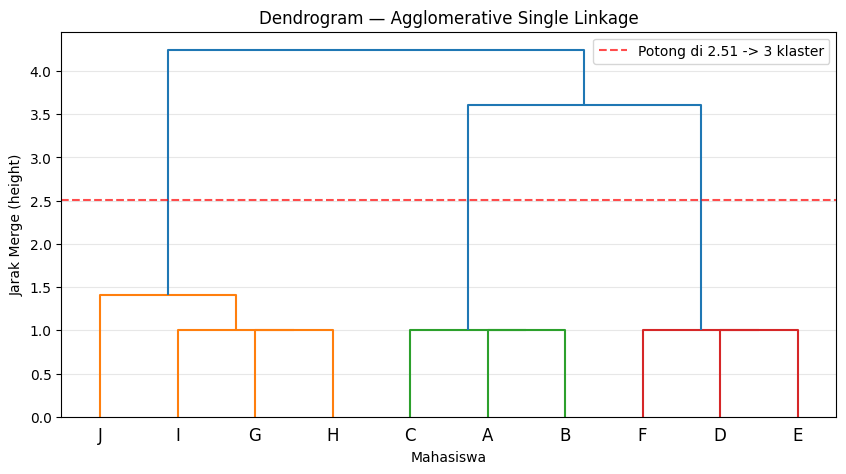

In [10]:
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=names, leaf_font_size=12, color_threshold=cut_height)
plt.axhline(y=cut_height, color='red', linestyle='--', alpha=0.7,
            label=f'Potong di {cut_height:.2f} -> {optimal_k} klaster')
plt.title('Dendrogram — Agglomerative Single Linkage')
plt.xlabel('Mahasiswa')
plt.ylabel('Jarak Merge (height)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 6. Hasil Klaster Final

Memotong dendrogram pada `optimal_k` klaster, lalu validasi dengan sklearn `AgglomerativeClustering`.

### Penjelasan kode

- `fcluster(Z, t=optimal_k, criterion='maxclust')` memotong dendrogram menjadi `optimal_k` klaster.
- `AgglomerativeClustering(n_clusters=optimal_k, linkage='single')` dijalankan sebagai validasi silang. Isi klaster harus sama (penomoran boleh beda).
- Scatter plot mewarnai titik sesuai klaster final.

In [11]:
label_scipy = fcluster(Z, t=optimal_k, criterion='maxclust')
ac = AgglomerativeClustering(n_clusters=optimal_k, linkage='single', metric='euclidean')
label_sklearn = ac.fit_predict(X)

df_label = data.copy()
df_label['Klaster (SciPy)'] = label_scipy
df_label['Klaster (sklearn)'] = label_sklearn
df_label

,Mhs,Tugas,Ujian,Klaster (SciPy),Klaster (sklearn)
0,A,1,2,2,2
1,B,2,2,2,2
2,C,2,3,2,2
3,D,5,5,3,1
4,E,6,5,3,1
5,F,5,6,3,1
6,G,9,9,1,0
7,H,9,8,1,0
8,I,8,9,1,0
9,J,10,10,1,0


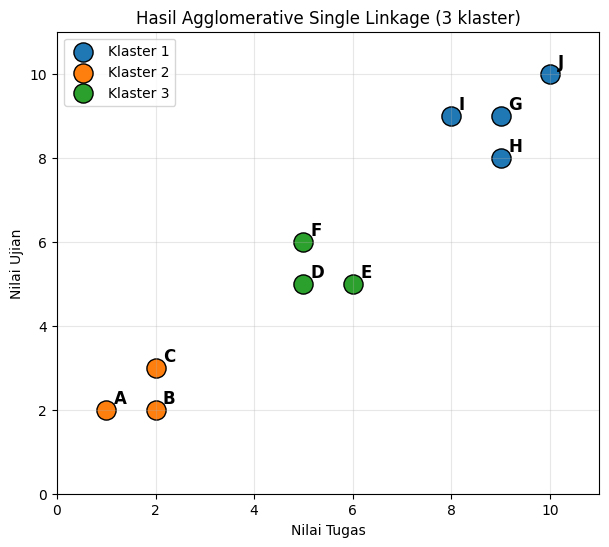

In [12]:
plt.figure(figsize=(7, 6))
cmap = plt.get_cmap('tab10')
for k in np.unique(label_scipy):
    pts = X[label_scipy == k]
    plt.scatter(pts[:, 0], pts[:, 1], color=cmap(k - 1), s=190, edgecolors='k', label=f'Klaster {k}')
for i, nm in enumerate(names):
    plt.annotate(nm, (X[i, 0] + 0.15, X[i, 1] + 0.15), fontsize=12, fontweight='bold')
plt.xlabel('Nilai Tugas'); plt.ylabel('Nilai Ujian')
plt.title(f'Hasil Agglomerative Single Linkage ({optimal_k} klaster)')
plt.legend(); plt.grid(alpha=0.3)
plt.xlim(0, 11); plt.ylim(0, 11)
plt.show()

## 7. Bukti: Jumlah Klaster Tergantung di Mana Dipotong

Untuk menegaskan bahwa jumlah klaster **mengikuti data / titik potong**, kita potong dendrogram pada 2, 3, dan 4 klaster lalu bandingkan.

### Penjelasan kode

- Loop `k = 2, 3, 4`: panggil `fcluster(Z, t=k, criterion='maxclust')` lalu gambar scatter per klaster.
- Terlihat: di **k=2** kelompok menengah ikut tergabung (kurang pas), di **k=3** ketiga kelompok terpisah bersih (paling sesuai data), di **k=4** salah satu kelompok mulai terpecah (over-segmentasi).

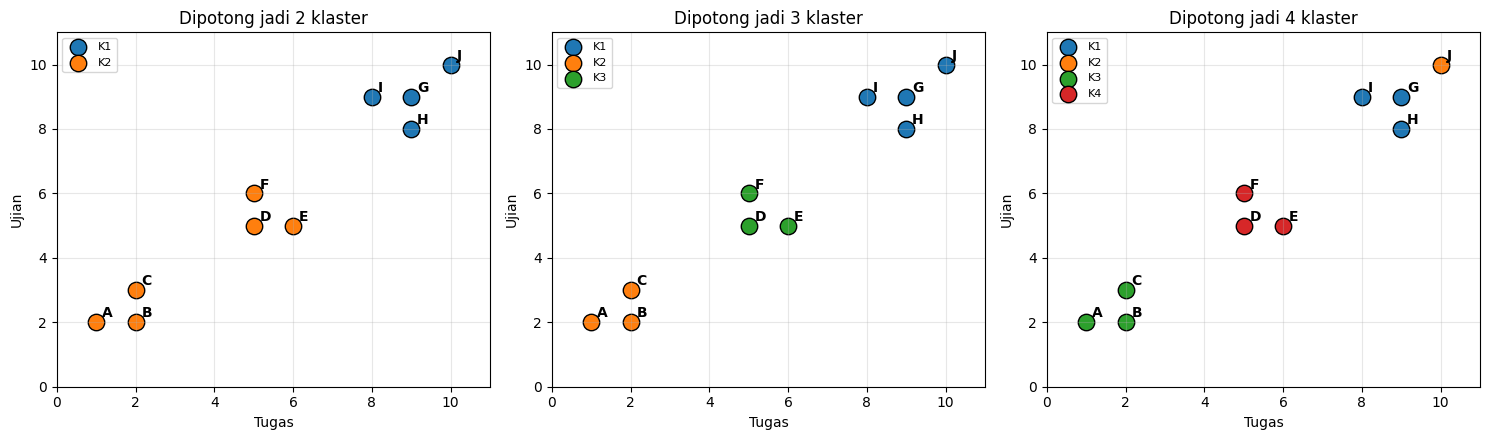

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, k in zip(axs, [2, 3, 4]):
    lab = fcluster(Z, t=k, criterion='maxclust')
    cmap = plt.get_cmap('tab10')
    for c in np.unique(lab):
        pts = X[lab == c]
        ax.scatter(pts[:, 0], pts[:, 1], color=cmap(c - 1), s=140, edgecolors='k', label=f'K{c}')
    for i, nm in enumerate(names):
        ax.annotate(nm, (X[i, 0] + 0.15, X[i, 1] + 0.15), fontsize=10, fontweight='bold')
    ax.set_title(f'Dipotong jadi {k} klaster')
    ax.set_xlabel('Tugas'); ax.set_ylabel('Ujian')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ax.set_xlim(0, 11); ax.set_ylim(0, 11)
plt.tight_layout()
plt.show()

## 8. Perbandingan Metode Linkage

Selain *single linkage*, ada pilihan lain dengan definisi jarak antar klaster berbeda:

| Method | Definisi | Karakter |
|--------|----------|----------|
| `single` | minimum antar anggota | rentan *chaining*, klaster bisa memanjang |
| `complete` | maksimum antar anggota | klaster lebih kompak |
| `average` | rata-rata semua pasangan | kompromi single dan complete |
| `ward` | minimalkan kenaikan SSE | klaster cenderung seimbang |

### Penjelasan kode

Loop 4 metode linkage, tiap metode digambar dendrogramnya pada subplot 2 × 2. Skala sumbu Y berbeda antar metode adalah wajar karena definisi jaraknya berbeda. Untuk data yang kelompoknya terpisah jelas seperti ini, semua metode umumnya tetap menghasilkan 3 klaster yang sama.

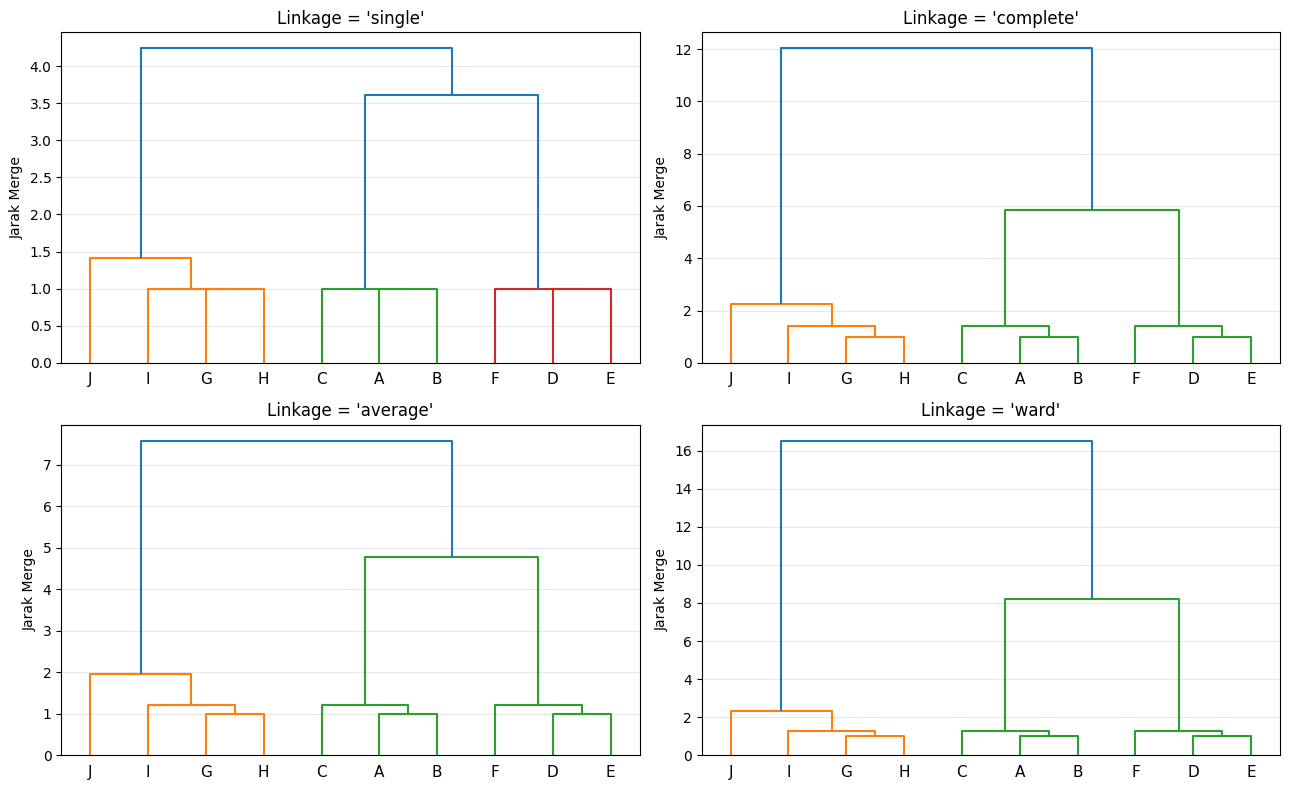

In [14]:
metode = ['single', 'complete', 'average', 'ward']
fig, axs = plt.subplots(2, 2, figsize=(13, 8))
for ax, m in zip(axs.flatten(), metode):
    Zm = linkage(X, method=m, metric='euclidean')
    dendrogram(Zm, labels=names, ax=ax, leaf_font_size=11)
    ax.set_title(f"Linkage = '{m}'")
    ax.set_ylabel('Jarak Merge')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Kesimpulan

1. Agglomerative clustering bekerja *bottom-up*: mulai dari $n$ klaster (tiap titik sendiri) hingga 1 klaster, dengan **9 iterasi** untuk 10 data.
2. **Matriks jarak diperbarui di setiap iterasi** dengan rumus single linkage $d(C_i \cup C_j, C_k) = \min(d(C_i,C_k), d(C_j,C_k))$. Section 3 menampilkan matriks lengkap tiap langkah untuk laporan manual.
3. Algoritma **tidak berhenti di 2 klaster**. Jumlah klaster final ditentukan dengan memotong dendrogram pada **gap (lompatan) tinggi merge terbesar**.
4. Untuk data ini gap terbesar memberi **3 klaster** (rendah, menengah, tinggi), bukan 2. Jika datanya berbeda, jumlah klaster bisa 2, 4, atau lebih, **tergantung sebaran data**.
5. Hasil manual cocok dengan SciPy `linkage` dan sklearn `AgglomerativeClustering` (Section 4 dan 6) sehingga perhitungan tervalidasi.
6. Kelebihan dibanding K-Means: **tidak perlu menentukan K di awal** dan memberi hirarki lengkap. Kekurangan: kompleksitas tinggi pada data besar.